# Estimativa de Profissionais de Tecnologia – Florianópolis (2023)

Este notebook estima o total de profissionais do setor de tecnologia em Florianópolis
combinando duas fontes complementares:

- **RAIS** (`basedosdados.br_me_rais.microdados_vinculos`): vínculos CLT ativos em 31/12/2023

**Setor de tecnologia:** grupos CNAE 26, 58, 61, 62, 63, 72 e 95.

**Município:** Florianópolis – SC (código IBGE `4205407`).

---

## 1. Carregamento dos dados

Os dados já foram extraídos do BigQuery e estão disponíveis como arquivos Parquet
hospedados no GitHub Releases. A leitura é feita diretamente via URL, sem necessidade
de conexão com o BigQuery ou credenciais do Google Cloud.

| Base | Fonte |
|---|---|
| RAIS – Vínculos CLT 2013–2023 | GitHub Releases – `data_rais_tech` |



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ── URLs dos arquivos no GitHub Releases ────────────────────────────────
URL_RAIS   = (
    "https://github.com/mvtp23/TCC/releases/download/"
    "data_rais_tech/vinculos_clt_2013_2023.parquet"
)


# ── Leitura ─────────────────────────────────────────────────────────────
print("Carregando RAIS...")
df_rais = pd.read_parquet(URL_RAIS)
print(f"  ✅ {len(df_rais):,} linhas | colunas: {list(df_rais.columns)}")



Carregando RAIS...
  ✅ 277,426 linhas | colunas: ['ano', 'id_municipio', 'sigla_uf', 'cnae_2', 'cnae_2_subclasse', 'tamanho_estabelecimento', 'qtd_vinculos_ativos', 'tamanho_desc', 'cnae_classe_desc']


## 2. Tradução de códigos da RAIS

Os campos `tamanho_estabelecimento` e `cnae_2` usam códigos numéricos.
Os dicionários abaixo substituem a consulta ao BigQuery.


In [2]:
# ── Dicionário: tamanho do estabelecimento ───────────────────────────────
# Fonte: RAIS – dicionário oficial (MTE)
tamanho_map = {
    "0":  "Ignorado",
    "1":  "Até 4",
    "2":  "DE 5 A 9",
    "3":  "De 5 a 9",
    "4":  "De 10 a 19",
    "5":  "De 20 a 49",
    "6":  "De 50 a 99",
    "7":  "De 100 a 249",
    "8":  "De 250 a 499",
    "9":  "De 500 a 999",
    "10": "1000 ou mais",
}

# ── Dicionário: grupo CNAE 2 dígitos ─────────────────────────────────────
cnae_map = {
    "58": "Edição e Edição Integrada à Impressão",
    "61": "Telecomunicações",
    "62": "Atividades dos Serviços de TI",
    "63": "Atividades de Prestação de Serviços de Informação",
    "72": "Pesquisa e Desenvolvimento Científico",
    "95": "Reparação e Manutenção de Equipamentos de TI",
}

# ── Aplica traduções ─────────────────────────────────────────────────────
df_rais["tamanho_desc"]    = df_rais["tamanho_estabelecimento"].astype(str).map(tamanho_map)
df_rais["cnae_classe_desc"] = df_rais["cnae_2"].astype(str).str[:2].map(cnae_map)

print("Tradução aplicada com sucesso.")
df_rais[["tamanho_estabelecimento","tamanho_desc","cnae_2","cnae_classe_desc"]].drop_duplicates().head(10)


Tradução aplicada com sucesso.


,tamanho_estabelecimento,tamanho_desc,cnae_2,cnae_classe_desc
0,4,De 10 a 19,61108,Telecomunicações
1,2,DE 5 A 9,61906,Telecomunicações
2,2,DE 5 A 9,63917,Atividades de Prestação de Serviços de Informação
3,2,DE 5 A 9,58123,Edição e Edição Integrada à Impressão
4,5,De 20 a 49,58191,Edição e Edição Integrada à Impressão
5,2,DE 5 A 9,58221,Edição e Edição Integrada à Impressão
6,4,De 10 a 19,58298,Edição e Edição Integrada à Impressão
7,5,De 20 a 49,61108,Telecomunicações
8,4,De 10 a 19,61906,Telecomunicações
9,3,De 5 a 9,61906,Telecomunicações


## 3. Consolidação – Estimativa total de profissionais de tecnologia (2023)

Combina as três fontes para chegar à estimativa total:

| Fonte | O que representa |
|---|---|
| RAIS | Vínculos CLT ativos em 31/12/2023 |


In [4]:
# Total CLT pela RAIS em 2023 para Florianópolis
total_clt = int(
    df_rais[
        (df_rais['id_municipio'] == '4205407') & 
        (df_rais['ano'] == 2023)
    ]['qtd_vinculos_ativos'].sum()
)

# Consolida todas as fontes
resumo = pd.DataFrame([
    {'fonte': 'RAIS – Vínculos CLT (2023)',                    'profissionais': total_clt},
])

resumo['percentual'] = (resumo['profissionais'] / resumo['profissionais'].sum() * 100).round(1)
total_geral = resumo['profissionais'].sum()

print(resumo.to_string(index=False))
print(f"\n{'='*55}")
print(f"TOTAL ESTIMADO: {total_geral:,} profissionais de tecnologia")
print(f"Referência ACATE 2024: 45.600")
print(f"{'='*55}")


                     fonte  profissionais  percentual
RAIS – Vínculos CLT (2023)          20168       100.0

TOTAL ESTIMADO: 20,168 profissionais de tecnologia
Referência ACATE 2024: 45.600


## 4. Análises da RAIS

Explorações adicionais com os dados de vínculos CLT.

In [5]:
# Evolução anual de empregos CLT por CNAE – Florianópolis
# Filtra apenas Florianópolis antes de agregar
empregos_por_cnae = (
    df_rais[df_rais["id_municipio"] == "4205407"]
    .groupby(["ano", "cnae_2", "cnae_classe_desc"])["qtd_vinculos_ativos"]
    .sum()
    .reset_index()
    .sort_values(["ano", "qtd_vinculos_ativos"], ascending=[True, False])
)
empregos_por_cnae.head(20)


,ano,cnae_2,cnae_classe_desc,qtd_vinculos_ativos
18,2013,63119,Atividades de Prestação de Serviços de Informação,12661
14,2013,62023,Atividades dos Serviços de TI,2377
13,2013,62015,Atividades dos Serviços de TI,1207
22,2013,72100,Pesquisa e Desenvolvimento Científico,1001
8,2013,61108,Telecomunicações,826
15,2013,62031,Atividades dos Serviços de TI,793
5,2013,58221,Edição e Edição Integrada à Impressão,586
16,2013,62040,Atividades dos Serviços de TI,547
17,2013,62091,Atividades dos Serviços de TI,389
10,2013,61418,Telecomunicações,288


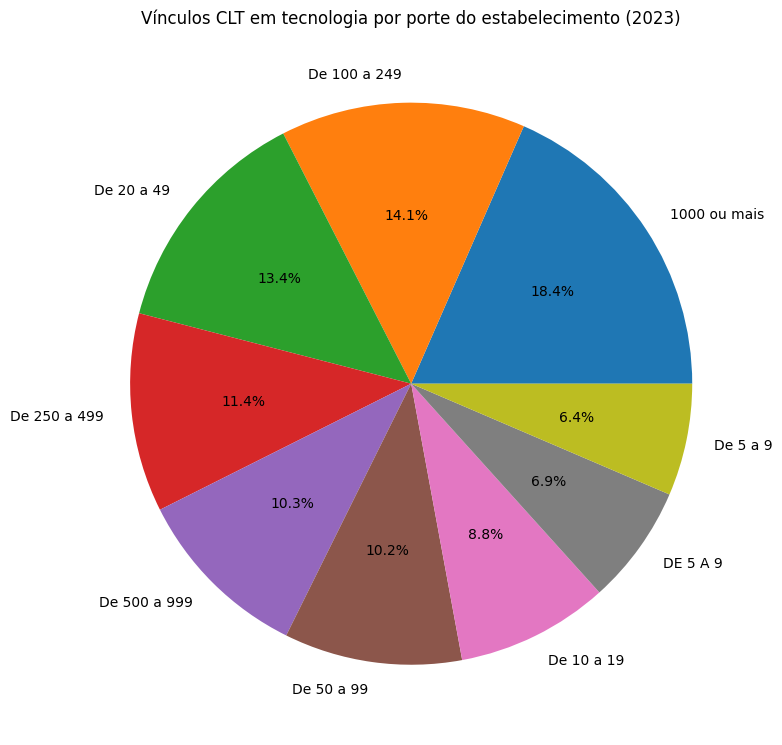

In [6]:
# Distribuição de vínculos CLT por porte de estabelecimento em 2023
df_2023 = df_rais[df_rais['ano'] == 2023]
porte_2023 = df_2023.groupby('tamanho_desc')['qtd_vinculos_ativos'].sum().reset_index()
porte_2023 = porte_2023.sort_values('qtd_vinculos_ativos', ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(
    porte_2023['qtd_vinculos_ativos'],
    labels=porte_2023['tamanho_desc'],
    autopct='%1.1f%%'
)
plt.title('Vínculos CLT em tecnologia por porte do estabelecimento (2023)')
plt.tight_layout()
plt.show()


## 5. Análise histórica – Florianópolis (2013–2023)

Evolução dos vínculos CLT ativos no setor de tecnologia em Florianópolis,
com três perspectivas:

1. **Série temporal total** – crescimento absoluto e CAGR do período
2. **Breakdown por CNAE** – quais grupos puxaram o crescimento
3. **Breakdown por porte** – distribuição entre micro, pequenas e grandes empresas

> Fonte: RAIS  – vínculos ativos em 31/12 de cada ano.
> Município: Florianópolis – SC (código IBGE ).

Vínculos CLT ativos – Florianópolis (2013–2023)
---------------------------------------------
  2013: 22,136  ████████████████████████████████████████████
  2014: 24,953  █████████████████████████████████████████████████
  2015: 25,476  ██████████████████████████████████████████████████
  2016: 11,033  ██████████████████████
  2017: 12,208  ████████████████████████
  2018: 13,315  ██████████████████████████
  2019: 12,836  █████████████████████████
  2020: 13,094  ██████████████████████████
  2021: 14,852  █████████████████████████████
  2022: 19,745  ███████████████████████████████████████
  2023: 20,168  ████████████████████████████████████████
---------------------------------------------
  Crescimento absoluto : +-1,968 empregos
  CAGR 2013-2023       : -0.9% a.a.


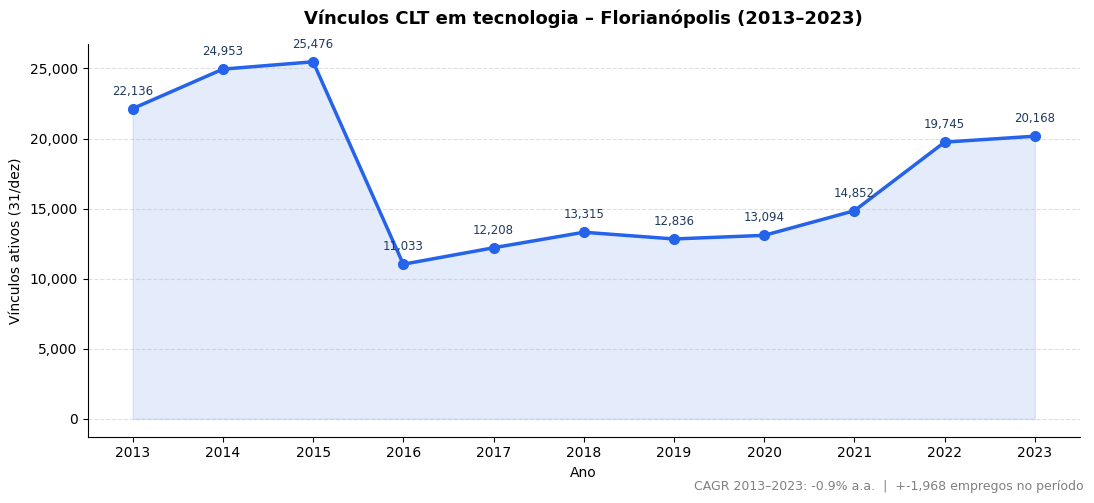

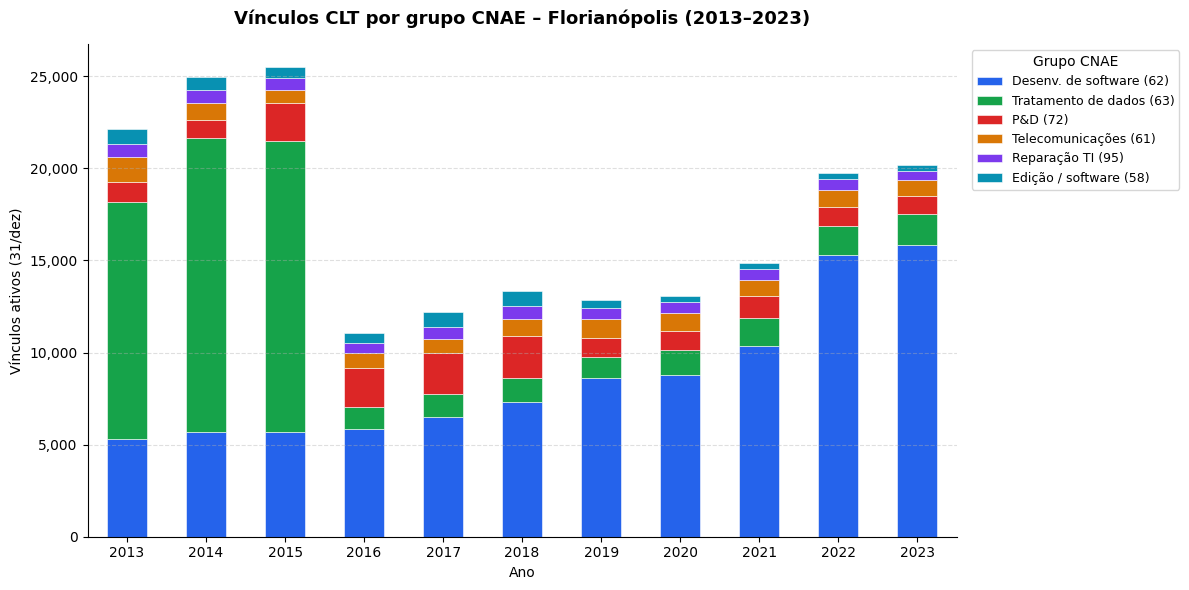

Participação por grupo CNAE (%) – 2013 vs 2023
--------------------------------------------------
  Desenv. de software (62)        24.0%  →   78.4%  (+54.4pp)
  Tratamento de dados (63)        58.0%  →    8.5%  (-49.4pp)
  P&D (72)                         4.9%  →    4.8%  (-0.1pp)
  Telecomunicações (61)            6.3%  →    4.2%  (-2.1pp)
  Reparação TI (95)                3.2%  →    2.6%  (-0.6pp)
  Edição / software (58)           3.6%  →    1.4%  (-2.1pp)


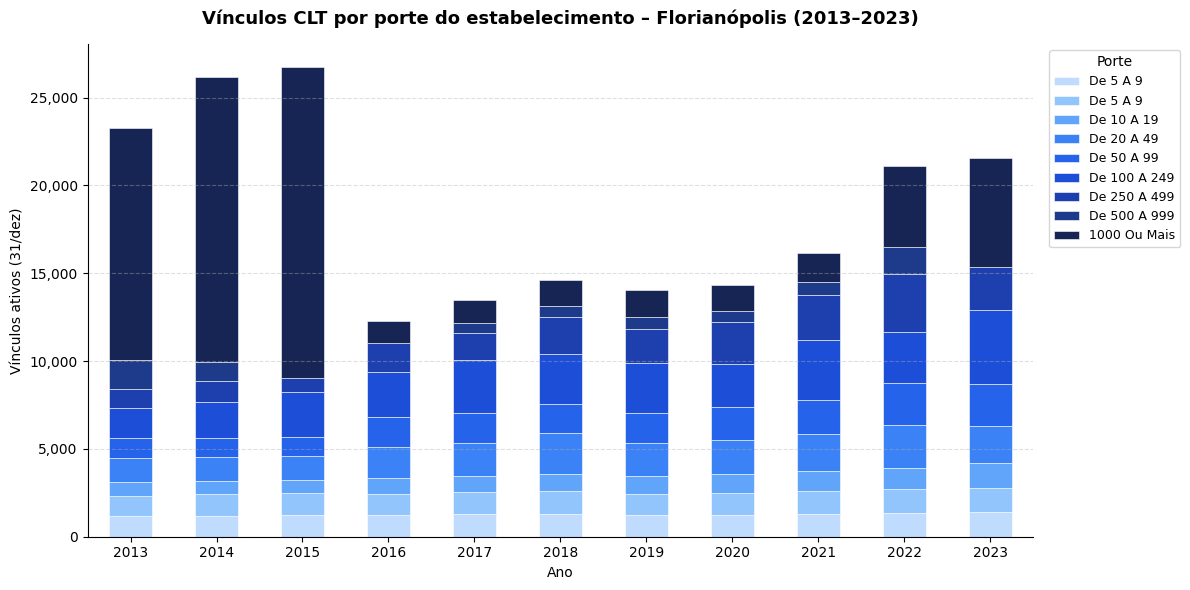

Variação anual – vínculos CLT Florianópolis
--------------------------------------------------
  2013→2014: ++2,817  (+12.7%)
  2014→2015: +  +523  (+2.1%)
  2015→2016: -14,443  (-56.7%)
  2016→2017: ++1,175  (+10.6%)
  2017→2018: ++1,107  (+9.1%)
  2018→2019:   -479  (-3.6%)
  2019→2020: +  +258  (+2.0%)
  2020→2021: ++1,758  (+13.4%)
  2021→2022: ++4,893  (+32.9%)
  2022→2023: +  +423  (+2.1%)


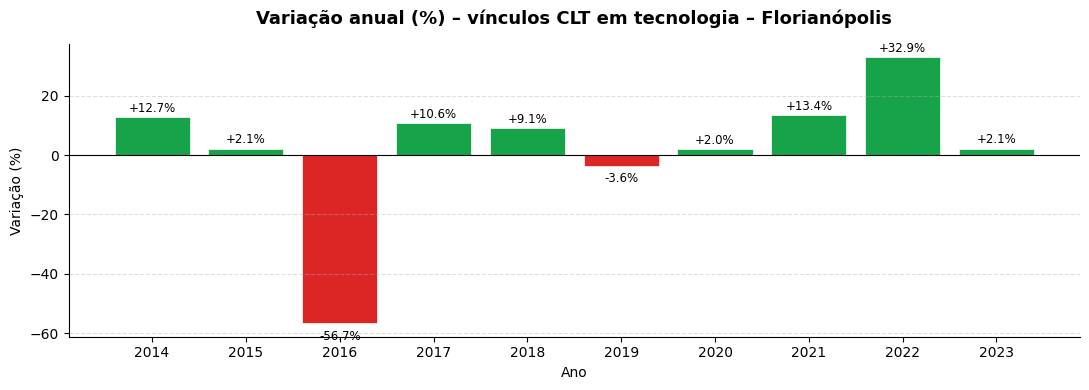

In [7]:
# ── 10. Análise histórica – Florianópolis (2013–2023) ───────────────────
# Filtra apenas Florianópolis
df_flp = df_rais[df_rais["id_municipio"] == "4205407"].copy()

# ── 10a. Série temporal total ────────────────────────────────────────────
serie_anual = (
    df_flp
    .groupby("ano")["qtd_vinculos_ativos"]
    .sum()
    .reset_index()
    .sort_values("ano")
)

# CAGR 2013-2023
v0 = serie_anual.loc[serie_anual["ano"] == 2013, "qtd_vinculos_ativos"].values[0]
v1 = serie_anual.loc[serie_anual["ano"] == 2023, "qtd_vinculos_ativos"].values[0]
cagr = ((v1 / v0) ** (1 / 10) - 1) * 100
crescimento_abs = v1 - v0

print("Vínculos CLT ativos – Florianópolis (2013–2023)")
print("-" * 45)
for _, row in serie_anual.iterrows():
    bar = "█" * int(row["qtd_vinculos_ativos"] / 500)
    print(f"  {int(row['ano'])}: {int(row['qtd_vinculos_ativos']):>6,}  {bar}")
print("-" * 45)
print(f"  Crescimento absoluto : +{crescimento_abs:,.0f} empregos")
print(f"  CAGR 2013-2023       : {cagr:.1f}% a.a.")

# ── Gráfico 1: linha temporal ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(serie_anual["ano"], serie_anual["qtd_vinculos_ativos"],
        marker="o", linewidth=2.5, color="#2563EB", markersize=7)
ax.fill_between(serie_anual["ano"], serie_anual["qtd_vinculos_ativos"],
                alpha=0.12, color="#2563EB")
for _, row in serie_anual.iterrows():
    ax.annotate(f"{int(row['qtd_vinculos_ativos']):,}",
                xy=(row["ano"], row["qtd_vinculos_ativos"]),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8.5, color="#1e3a5f")
ax.set_title("Vínculos CLT em tecnologia – Florianópolis (2013–2023)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Ano", fontsize=10)
ax.set_ylabel("Vínculos ativos (31/dez)", fontsize=10)
ax.set_xticks(serie_anual["ano"])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.99, 0.01, f"CAGR 2013–2023: {cagr:.1f}% a.a.  |  +{crescimento_abs:,.0f} empregos no período",
         ha="right", fontsize=9, color="gray")
plt.tight_layout()
plt.show()

# ── 10b. Breakdown por CNAE ──────────────────────────────────────────────
# Mapeia prefixo CNAE → nome legível
cnae_label = {
    "58": "Edição / software (58)",
    "61": "Telecomunicações (61)",
    "62": "Desenv. de software (62)",
    "63": "Tratamento de dados (63)",
    "72": "P&D (72)",
    "95": "Reparação TI (95)",
}
df_flp["grupo_cnae"] = df_flp["cnae_2"].str[:2].map(cnae_label).fillna("Outros")

serie_cnae = (
    df_flp
    .groupby(["ano", "grupo_cnae"])["qtd_vinculos_ativos"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

# Ordena colunas pelo total decrescente
serie_cnae = serie_cnae[serie_cnae.sum().sort_values(ascending=False).index]

colors = ["#2563EB", "#16A34A", "#DC2626", "#D97706", "#7C3AED", "#0891B2", "#6B7280"]
fig, ax = plt.subplots(figsize=(12, 6))
serie_cnae.plot(kind="bar", stacked=True, ax=ax, color=colors[:len(serie_cnae.columns)],
                edgecolor="white", linewidth=0.4)
ax.set_title("Vínculos CLT por grupo CNAE – Florianópolis (2013–2023)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Ano", fontsize=10)
ax.set_ylabel("Vínculos ativos (31/dez)", fontsize=10)
ax.set_xticklabels([str(a) for a in serie_cnae.index], rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title="Grupo CNAE", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Tabela: participação de cada CNAE em 2013 vs 2023
print("Participação por grupo CNAE (%) – 2013 vs 2023")
print("-" * 50)
total_2013 = serie_cnae.loc[2013].sum()
total_2023 = serie_cnae.loc[2023].sum()
for col in serie_cnae.columns:
    p13 = serie_cnae.loc[2013, col] / total_2013 * 100 if total_2013 > 0 else 0
    p23 = serie_cnae.loc[2023, col] / total_2023 * 100 if total_2023 > 0 else 0
    delta = p23 - p13
    sinal = "+" if delta >= 0 else ""
    print(f"  {col:<30} {p13:5.1f}%  →  {p23:5.1f}%  ({sinal}{delta:.1f}pp)")

# ── 10c. Breakdown por porte ─────────────────────────────────────────────
# Normaliza descrição (há variações de capitalização no dicionário)
df_flp["porte_norm"] = df_flp["tamanho_desc"].str.strip().str.title().fillna("Não Informado")

serie_porte = (
    df_flp
    .groupby(["ano", "porte_norm"])["qtd_vinculos_ativos"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

# Ordena portes de forma lógica (crescente de tamanho)
ordem_porte = [
    "Até 4", "De 5 A 9", "De 5 A 9", "De 10 A 19",
    "De 20 A 49", "De 50 A 99", "De 100 A 249",
    "De 250 A 499", "De 500 A 999", "1000 Ou Mais", "Não Informado"
]
cols_ordenadas = [c for c in ordem_porte if c in serie_porte.columns]
cols_restantes = [c for c in serie_porte.columns if c not in cols_ordenadas]
serie_porte = serie_porte[cols_ordenadas + cols_restantes]

colors_porte = [
    "#bfdbfe", "#93c5fd", "#60a5fa", "#3b82f6",
    "#2563EB", "#1d4ed8", "#1e40af", "#1e3a8a", "#172554", "#0f172a", "#9ca3af"
]
fig, ax = plt.subplots(figsize=(12, 6))
serie_porte.plot(kind="bar", stacked=True, ax=ax,
                 color=colors_porte[:len(serie_porte.columns)],
                 edgecolor="white", linewidth=0.4)
ax.set_title("Vínculos CLT por porte do estabelecimento – Florianópolis (2013–2023)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Ano", fontsize=10)
ax.set_ylabel("Vínculos ativos (31/dez)", fontsize=10)
ax.set_xticklabels([str(a) for a in serie_porte.index], rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(title="Porte", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# ── 10d. Variação ano a ano ──────────────────────────────────────────────
serie_anual["var_abs"]  = serie_anual["qtd_vinculos_ativos"].diff()
serie_anual["var_pct"]  = serie_anual["qtd_vinculos_ativos"].pct_change() * 100

print("Variação anual – vínculos CLT Florianópolis")
print("-" * 50)
for _, row in serie_anual.dropna().iterrows():
    sinal = "+" if row["var_abs"] >= 0 else ""
    print(f"  {int(row['ano'])-1}→{int(row['ano'])}: {sinal}{int(row['var_abs']):>+6,}  ({sinal}{row['var_pct']:.1f}%)")

fig, ax = plt.subplots(figsize=(11, 4))
colors_var = ["#16A34A" if v >= 0 else "#DC2626"
              for v in serie_anual["var_pct"].dropna()]
anos_var = serie_anual["ano"].iloc[1:].astype(int)
ax.bar(anos_var, serie_anual["var_pct"].dropna(), color=colors_var,
       edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)
for x, y in zip(anos_var, serie_anual["var_pct"].dropna()):
    offset = 0.4 if y >= 0 else -1.2
    ax.annotate(f"{y:+.1f}%", xy=(x, y), xytext=(0, offset * 10),
                textcoords="offset points", ha="center", fontsize=8.5)
ax.set_title("Variação anual (%) – vínculos CLT em tecnologia – Florianópolis",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Ano", fontsize=10)
ax.set_ylabel("Variação (%)", fontsize=10)
ax.set_xticks(anos_var)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 6. Salvando resultados

In [8]:
# Salva a tabela de consolidação final
resumo.to_csv("estimativa_profissionais_tech_florianopolis_2023.csv", index=False, encoding='utf-8-sig')

# Salva os dados detalhados da RAIS
df_rais.to_parquet("rais_tecnologia.parquet", index=False)
df_rais.to_csv("rais_tecnologia.csv", index=False, encoding='utf-8-sig')

print("✅ Arquivos salvos:")
print("  - estimativa_profissionais_tech_florianopolis_2023.csv")
print("  - rais_tecnologia.parquet")
print("  - rais_tecnologia.csv")


✅ Arquivos salvos:
  - estimativa_profissionais_tech_florianopolis_2023.csv
  - rais_tecnologia.parquet
  - rais_tecnologia.csv
